# Package

In [5]:
# ==========================================
# Chargement
# ==========================================
import os
import pickle
import joblib
import numpy as np
import pandas as pd

from __future__ import annotations
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple, Union

from dateutil.relativedelta import relativedelta

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Chargement des résultats

In [6]:
# ---------- Helpers ----------

def load_any(path):
    """Charge un objet avec joblib puis pickle si besoin."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Fichier introuvable: {path}")
    try:
        return joblib.load(path)
    except Exception:
        with open(path, "rb") as f:
            return pickle.load(f)

def load_with_fallbacks(primary_path, *alt_paths, expect_type=None, label=None):
    """
    Charge primary_path puis essaie les alt_paths en fallback.
    - expect_type: type attendu (ex: dict), si fourni on vérifie isinstance.
    - label: nom lisible pour logs (ex: 'Ridge bundle OOS').
    """
    name = f" ({label})" if label else ""
    try:
        obj = load_any(primary_path)
        if expect_type and not isinstance(obj, expect_type):
            print(f"⚠️ Type inattendu{name} pour {primary_path}: {type(obj)} (attendu {expect_type}).")
        else:
            return obj
    except Exception as e:
        print(f"ℹ️ Impossible de charger {primary_path}{name} : {e}")

    for p in alt_paths:
        try:
            obj = load_any(p)
            print(f"ℹ️ Fallback utilisé{name} → {p}")
            if expect_type and not isinstance(obj, expect_type):
                print(f"⚠️ Type inattendu{name} pour {p}: {type(obj)} (attendu {expect_type}).")
            return obj
        except Exception as e:
            print(f"ℹ️ Fallback raté{name} → {p} : {e}")

    print(f"⚠️ Aucun fichier disponible{name} (essayé: {[primary_path, *alt_paths]})")
    return None

def try_read_meta(path):
    """Lit un CSV méta. Tente index_col=0 puis sans index si échec."""
    for use_index in (0, None):
        try:
            meta = pd.read_csv(path, index_col=use_index)
            # Si 1 colonne, exposer Series
            if isinstance(meta, pd.DataFrame) and meta.shape[1] == 1:
                meta = meta.iloc[:, 0]
            return meta
        except Exception as e:
            last_err = e
    print(f"⚠️ Impossible de lire {path} : {last_err}")
    return None

def safe_meta_print(meta, keys, title="Méta"):
    """Affiche les clés demandées sans lever d'erreur si elles manquent."""
    if meta is None:
        print("⚠️ Pas de méta disponible.")
        return
    if isinstance(meta, pd.Series):
        d = meta.to_dict()
    elif isinstance(meta, pd.DataFrame):
        d = meta.iloc[0].to_dict() if len(meta) else {}
    elif isinstance(meta, dict):
        d = meta
    else:
        print(f"(info) Type de méta inattendu: {type(meta)}")
        d = {}

    print(f"\n--- {title} (clé: valeur) ---")
    for k in keys:
        print(f"{k}: {d.get(k, None)}")

def _normalize_month_start(s):
    s = pd.to_datetime(s, errors="coerce")
    if isinstance(s, pd.Series):
        return s.dt.to_period("M").dt.to_timestamp(how="start")
    if isinstance(s, pd.DatetimeIndex):
        return s.to_period("M").to_timestamp(how="start")
    return pd.Timestamp(s).to_period("M").to_timestamp(how="start")

def ensure_ms_index_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.index = pd.to_datetime(out.index).to_period("M").to_timestamp(how="start")
    return out.sort_index().asfreq("MS")

def ensure_features_present(df: pd.DataFrame, features: list[str], target_col: str | None = None):
    missing = [c for c in (features or []) if c not in df.columns]
    if target_col is not None and target_col not in df.columns:
        missing.append(target_col)
    if missing:
        raise ValueError(f"Colonnes manquantes dans le DataFrame: {missing}")

def make_exp_from_loaded(*, models, features, train_periods, preprocs=None, step_months: int = 12) -> dict:
    if not isinstance(models, (list, tuple)) or len(models) == 0:
        raise ValueError("'models' doit être une liste non vue.")
    if not isinstance(features, (list, tuple)) or len(features) == 0:
        raise ValueError("'features' doit être une liste non vide.")
    if not isinstance(train_periods, (list, tuple)) or len(train_periods) != len(models):
        raise ValueError("'train_periods' doit avoir la même longueur que 'models'.")
    if preprocs is not None and len(preprocs) != len(models):
        raise ValueError("'preprocs' doit avoir la même longueur que 'models' si fourni.")
    return {
        "models":        list(models),
        "features":      list(features),
        "preprocs":      list(preprocs) if preprocs is not None else None,
        "train_periods": list(pd.to_datetime(pd.Index(train_periods))),
        "step_months":   int(step_months),
    }

def exp_from_linreg_bundle_no_refit(linreg_bundle: dict) -> dict:
    if not isinstance(linreg_bundle, dict):
        raise ValueError("linreg_bundle invalide (pas un dict).")
    params = linreg_bundle.get("params", {}) or {}
    features = params.get("features", linreg_bundle.get("features", None))
    if not features:
        raise ValueError("Features absentes dans le bundle (params.features).")
    models = linreg_bundle.get("models", None)
    if not isinstance(models, (list, tuple)) or len(models) == 0:
        raise RuntimeError(
            "Ce bundle ne contient pas la liste des modèles par fenêtre ('models'). "
            "Sauvegarde les modèles lors de l'apprentissage, puis recharge."
        )
    preprocs = linreg_bundle.get("preprocs", None)
    if preprocs is not None and len(preprocs) != len(models):
        raise RuntimeError("'preprocs' n'a pas la même longueur que 'models'.")
    train_periods = linreg_bundle.get("train_fit_dates", None)
    if train_periods is None or len(train_periods) != len(models):
        raise RuntimeError("'train_fit_dates' manquant ou de longueur différente de 'models'.")
    return {
        "models":        list(models),
        "features":      list(features),
        "preprocs":      list(preprocs) if preprocs is not None else None,
        "train_periods": list(pd.to_datetime(pd.Index(train_periods))),
        "step_months":   12,
    }

def extract_last_model_from_bundle(bundle: dict, model_key="models"):
    """Récupère le dernier modèle depuis un bundle, sinon None."""
    try:
        if isinstance(bundle, dict) and model_key in bundle and bundle[model_key]:
            return bundle[model_key][-1]
    except Exception as e:
        print(f"⚠️ Impossible d'extraire le dernier modèle: {e}")
    return None

In [10]:
from pathlib import Path

ARTIFACT_DIR = Path.cwd()   # ajuste si besoin

# ----------------------------
# AR(1)
# ----------------------------
AR1_BUNDLE     = ARTIFACT_DIR / "AR1_h12_oos_bundle.pkl"
AR1_LAST_PKL   = ARTIFACT_DIR / "AR1_last_trained_model.pkl"
AR1_LAST_META  = ARTIFACT_DIR / "AR1_last_trained_model_meta.csv"

# ----------------------------
# AR(p)
# ----------------------------
ARp_BUNDLE     = ARTIFACT_DIR / "ARp_h12_oos_bundle.pkl"
ARp_LAST_PKL   = ARTIFACT_DIR / "ARp_last_trained_model.pkl"
ARp_LAST_META  = ARTIFACT_DIR / "ARp_last_trained_model_meta.csv"

# ----------------------------
# Linear Regression (NO LAGS)
# ----------------------------
LINREG_PKL        = ARTIFACT_DIR / "linear_regression.pkl"
LINREG_META       = ARTIFACT_DIR / "linear_regression_meta.csv"

LINREG_LAST_PKL   = ARTIFACT_DIR / "LINREG_last_trained_model.pkl"
LINREG_LAST_META  = ARTIFACT_DIR / "LINREG_last_trained_model_meta.csv"
LINREG_BUNDLE     = ARTIFACT_DIR / "LINREG_h12_oos_bundle.pkl"

In [13]:
# -*- coding: utf-8 -*-
import os
import pandas as pd

# ==============================================================
# ✅ Helper CSV fallback (utilise try_read_meta existante)
# ==============================================================

def try_read_meta_with_fallbacks(primary_path, *alt_paths, label=None):
    name = f" ({label})" if label else ""
    for p in (primary_path, *alt_paths):
        if p is None:
            continue
        if not os.path.exists(str(p)):
            continue
        meta = try_read_meta(str(p))  # fonction existante
        if meta is not None:
            print(f"ℹ️ Meta CSV chargé{name} → {p}")
            return meta
    print(f"⚠️ Aucun CSV méta disponible{name} (essayé: {[primary_path, *alt_paths]})")
    return None


# ==============================================================
# ✅ Helpers bundle
# ==============================================================

def is_bundle(x):
    return isinstance(x, dict) and any(k in x for k in (
        "params", "models", "train_fit_dates", "oos", "oos_predictions", "forecasts"
    ))


def load_bundle_or_model(*paths, label=None):
    """
    Charge le premier fichier existant parmi paths via load_with_fallbacks.
    Retourne: (bundle, model)
    """
    obj = load_with_fallbacks(
        *[str(p) for p in paths if p is not None],
        expect_type=None,
        label=label
    )
    if obj is None:
        return None, None
    if is_bundle(obj):
        return obj, None
    return None, obj


# ==============================================================
# ✅ Chargement — Linear Regression (SANS bundle, SANS last model)
# ==============================================================

print("\n=== Chargement Linear Regression (sans lags) ===")

linreg_bundle = None
linreg_model = load_any(LINREG_PKL)   # ← SEUL fichier modèle LR
linreg_meta = try_read_meta_with_fallbacks(
    LINREG_META,
    label="LINREG meta"
)

print("LINREG model type:", type(linreg_model))


# ==============================================================
# ✅ Chargement — AR(1)
# ==============================================================

print("\n=== Chargement AR(1) ===")

ar1_bundle, ar1_model = load_bundle_or_model(
    AR1_BUNDLE,
    AR1_LAST_PKL,
    AR1_PKL,
    label="AR1"
)

ar1_meta = try_read_meta_with_fallbacks(
    AR1_LAST_META,
    label="AR1 meta"
)


# ==============================================================
# ✅ Chargement — AR(p)
# ==============================================================

print("\n=== Chargement AR(p) ===")

arp_bundle, arp_model = load_bundle_or_model(
    ARp_BUNDLE,        # bundle OOS
    ARp_LAST_PKL,      # last trained model
    label="ARp"
)

arp_meta = try_read_meta_with_fallbacks(
    ARp_LAST_META,
    label="ARp meta"
)


# ==============================================================
# ✅ Récapitulatif minimal
# ==============================================================

loaded = {
    "AR1": {
        "bundle": ar1_bundle,
        "model":  ar1_model,
        "meta":   ar1_meta,
    },
    "ARp": {
        "bundle": arp_bundle,
        "model":  arp_model,
        "meta":   arp_meta,
    },
    "LINREG": {
        "bundle": None,
        "model":  linreg_model,
        "meta":   linreg_meta,
    },
}

print("\n=== Récap chargements ===")
for k, v in loaded.items():
    ok = (v["bundle"] is not None) or (v["model"] is not None)
    print(f"{k:10s}: {'OK' if ok else '—'}")



=== Chargement Linear Regression (sans lags) ===
ℹ️ Meta CSV chargé (LINREG meta) → d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\3_notebook\linear_regression_meta.csv
LINREG model type: <class 'dict'>

=== Chargement AR(1) ===
ℹ️ Meta CSV chargé (AR1 meta) → d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\3_notebook\AR1_last_trained_model_meta.csv

=== Chargement AR(p) ===
ℹ️ Meta CSV chargé (ARp meta) → d:\Portofolio Data science\Time Series\Explainable_AI_Forecast_and_explain_the_Unemployment_of_USA\3_notebook\ARp_last_trained_model_meta.csv

=== Récap chargements ===
AR1       : OK
ARp       : OK
LINREG    : OK


In [16]:
from pathlib import Path

print("Fichiers présents ?")

for name, p in {
    "LINREG_PKL":  LINREG_PKL,
    "LINREG_META": LINREG_META,
}.items():
    print(f"{name:<12} : {'OK' if Path(p).exists() else 'ABSENT'}")

# Chargement rapide
linreg = load_any(LINREG_PKL) if Path(LINREG_PKL).exists() else None

def label(x):
    return (x.get("params", {}).get("model")
            if isinstance(x, dict) else
            (x.__class__.__name__ if x is not None else None))

print("\nLabel modèle :")
print("LINREG :", label(linreg))

Fichiers présents ?
LINREG_PKL   : OK
LINREG_META  : OK

Label modèle :
LINREG : LinearRegression


In [30]:
linreg_bundle = load_any(LINREG_PKL)   # ou pickle.load(open(...))


print("Keys:", linreg_bundle.keys())
print("oos_predictions shape:", linreg_bundle["oos_predictions"].shape)
print(linreg_bundle["oos_predictions"].head())

Keys: dict_keys(['oos_predictions', 'params', 'meta', 'train_fit_dates', 'models', 'preprocs'])
oos_predictions shape: (741, 6)
        date    y_pred  y_true  y_pred_base  y_pred_p05  y_pred_p95
0 1963-12-01 -0.716835     0.0    -0.288306   -1.181973   -0.177450
1 1964-01-01 -0.244223    -0.1    -0.180196   -1.125814    0.670957
2 1964-02-01  1.109324    -0.5     1.288267   -0.095926    2.216658
3 1964-03-01  0.940781    -0.3     1.324047   -0.629778    2.610680
4 1964-04-01  1.256649    -0.4     1.284993    0.123922    2.339940


# Etablir de dataframe des résultats.

In [31]:
# ========= Standardisation & fusion (patch LINREG vs LINREG_LAGS) =========
# 1) Récupérer les bundles AVEC leurs noms (indispensable pour trancher LINREG)
_bundle_items = [
    ("ar1_bundle",          globals().get("ar1_bundle")),
    ("arp_bundle",          globals().get("arp_bundle")),
    ("linreg_bundle",       globals().get("linreg_bundle")),
    ("linreg_lags_bundle",  globals().get("linreg_lags_bundle")),
    ("ridge_bundle",        globals().get("ridge_bundle")),
    ("ridge_lags_bundle",   globals().get("ridge_lags_bundle")),
    ("lgbm_bundle",         globals().get("lgbm_bundle")),
    ("lgbm_lags_bundle",    globals().get("lgbm_lags_bundle")),
]
available_bundles = [(name, b) for (name, b) in _bundle_items if isinstance(b, dict)]

if not available_bundles:
    raise RuntimeError("Aucun bundle dispo.")

import re
import pandas as pd

def _infer_ar_order_from_params(params: dict):
    if not isinstance(params, dict): return None
    if isinstance(params.get("lag"), int): return params["lag"]
    if isinstance(params.get("p"), int):   return params["p"]
    ordv = params.get("order")
    if isinstance(ordv, (list, tuple)) and ordv and isinstance(ordv[0], int):
        return ordv[0]
    p_grid = params.get("p_grid")
    if isinstance(p_grid, (list, tuple)) and p_grid:
        try:
            uniq = sorted({int(x) for x in p_grid if x is not None})
        except Exception:
            return None
        return 1 if uniq == [1] else (max(uniq) if uniq else None)
    return None

def _canon_base_from_label_and_params(label: str, params: dict) -> str:
    s = str(label or "").strip()
    base = s.split("(")[0].strip()
    base = re.sub(r"(?i)\blightgbm\s*\+\s*bagging\b", "LightGBM", base)
    low = base.lower()
    if low == "ar(1)": return "AR1"
    if low == "ar(p)": return "ARP"
    if low == "ar":
        p = _infer_ar_order_from_params(params or {})
        if p == 1: return "AR1"
        if isinstance(p, int) and p >= 2: return "ARP"
        return "AR"
    if low == "linearregression": return "LINREG"
    if low == "ridge":            return "RIDGE"
    if low == "lightgbm":         return "LGBM"
    return base.upper().replace(" ", "_").replace("-", "_")

def _label_has_lags(label: str) -> bool:
    return bool(re.search(r"(?i)\bwith[_\s]*unrate_lags\b", str(label or "")))

def _has_lag_columns(features) -> bool:
    if features is None: return False
    try: cols = list(features)
    except Exception: return False
    for c in cols:
        if re.search(r"(?i)\b(unrate[_\s]*lags?|lag(_?\d+)?|lags?(_?\d+)?)\b", str(c)):
            return True
    return False

def _struct_has_lags(b: dict) -> bool:
    if not isinstance(b, dict): return False
    params = b.get("params") or {}
    feats  = b.get("features", None) or params.get("features", None)
    if any(bool(params.get(k)) for k in ("lags_h","with_lags","use_lags")): return True
    if _has_lag_columns(feats): return True
    return False

def _bundle_has_lags_general(b: dict) -> bool:
    if _struct_has_lags(b): return True
    params = b.get("params") or {}
    if _label_has_lags(params.get("model")): return True
    try:
        ok, _, _ = detect_lags(b)  # si dispo dans ton script
        return bool(ok)
    except Exception:
        return False

def _canon_method_name_from_bundle(bundle_name: str, b: dict) -> str:
    """Force LINREG/LINREG_LAGS via le NOM du bundle ; autres via règle générale."""
    params = (b.get("params") or {})
    base   = _canon_base_from_label_and_params(params.get("model"), params)

    # 🔒 RÈGLE cible: régler uniquement LINREG
    if base == "LINREG":
        if bundle_name == "linreg_lags_bundle": return "LINREG_LAGS"
        if bundle_name == "linreg_bundle":      return "LINREG"
        # fallback si renommé : structure sinon LINREG
        return "LINREG_LAGS" if _struct_has_lags(b) else "LINREG"

    # Autres familles: lags via règle générale
    return f"{base}_LAGS" if _bundle_has_lags_general(b) else base

# 3) Assemblage canonisé par bundle AVANT concat
dfs = []
for bundle_name, b in available_bundles:
    if "oos_predictions" not in b: 
        continue
    df_b = build_df_from_bundle(b)
    if df_b.empty: 
        continue
    df_b["method"] = _canon_method_name_from_bundle(bundle_name, b)
    dfs.append(df_b)

df_pred_long = (
    pd.concat(dfs, ignore_index=True)
      .dropna(subset=["date","true","pred"])
      .assign(date=lambda d: pd.to_datetime(d["date"], errors="coerce"))
      .sort_values(["date","method"])
      .reset_index(drop=True)
)

# Optionnel: supprimer d'éventuels doublons stricts (utile si un OOS a été concaténé 2x à la source)
# df_pred_long = df_pred_long.drop_duplicates(subset=["date","method","true","pred"]).reset_index(drop=True)

print("Méthodes :", sorted(df_pred_long["method"].unique().tolist()))
print(df_pred_long["method"].value_counts())

Méthodes : ['AR1', 'ARP', 'LINREG']
method
AR1       741
ARP       741
LINREG    741
Name: count, dtype: int64


In [32]:
# ====== Imports requis (n'écrasent rien) ======
import numpy as np
import pandas as pd
import re
from dateutil.relativedelta import relativedelta
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =============== STANDARDISATION ===============
def standardize_oos_predictions(
    oos: pd.DataFrame,
    *,
    method_name=None,
    date_candidates=("date","dates"),
    true_candidates=("y_true","true","target","y"),
    pred_candidates=("y_pred","pred","prediction","forecast","yhat"),
) -> pd.DataFrame:
    d = oos.copy()
    if d.index.name is not None:
        d = d.reset_index()

    cols = {c.lower(): c for c in d.columns}

    def _pick(cands):
        for k in cands:
            if k in cols:
                return cols[k]
        return None

    date_col = _pick(date_candidates)
    true_col = _pick(true_candidates)
    pred_col = _pick(pred_candidates)
    if not (date_col and true_col and pred_col):
        raise ValueError(f"Colonnes manquantes (date/true/pred) dans {d.columns.tolist()}")

    out = d[[date_col, true_col, pred_col]].rename(
        columns={date_col: "date", true_col: "true", pred_col: "pred"}
    )
    out["date"] = _normalize_month_start(out["date"])  # helper existant
    if method_name:
        out["method"] = method_name
    return out.reset_index(drop=True)

def build_df_from_bundle(bundle: dict, default_method: str = "Model") -> pd.DataFrame:
    if not isinstance(bundle, dict) or "oos_predictions" not in bundle:
        return pd.DataFrame(columns=["date", "true", "pred", "method"])
    params = bundle.get("params", {}) or {}
    method = params.get("model", default_method)
    return standardize_oos_predictions(bundle["oos_predictions"], method_name=method)

def assemble_long_from_bundles(*bundles: dict) -> pd.DataFrame:
    dfs = [build_df_from_bundle(b) for b in bundles if isinstance(b, dict)]
    dfs = [d for d in dfs if not d.empty]
    if not dfs:
        return pd.DataFrame(columns=["date", "true", "pred", "method"])
    out = pd.concat(dfs, ignore_index=True)
    out["date"] = pd.to_datetime(out["date"], errors="coerce")
    out = out.dropna(subset=["date", "true", "pred"]).sort_values(["date", "method"]).reset_index(drop=True)
    return out


In [33]:
# =================== SCORES ====================
def scores_basic(df: pd.DataFrame) -> dict:
    if df.empty:
        return {"MAE": np.nan, "RMSE": np.nan, "R2": np.nan}
    mae  = float(mean_absolute_error(df["true"], df["pred"]))
    rmse = float(np.sqrt(mean_squared_error(df["true"], df["pred"])))
    r2   = float(r2_score(df["true"], df["pred"])) if len(df) > 1 else np.nan
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

def scores_by_method_and_window(
    df_long: pd.DataFrame,
    eval_window=("1983-01-01", "1989-12-31"),
    test_window=("1990-01-01", "2025-12-31"),
) -> dict:
    if df_long.empty:
        return {"validation": {}, "test": {}}
    df = df_long.copy()
    df["date"] = pd.to_datetime(df["date"])
    e0, e1 = map(pd.Timestamp, eval_window)
    t0, t1 = map(pd.Timestamp, test_window)

    out = {"validation": {}, "test": {}}
    for m in sorted(df["method"].unique()):
        dval = df[(df["method"] == m) & (df["date"] >= e0) & (df["date"] <= e1)]
        dtes = df[(df["method"] == m) & (df["date"] >= t0) & (df["date"] <= t1)]
        out["validation"][m] = scores_basic(dval)
        out["test"][m]       = scores_basic(dtes)
    return out


In [34]:
# ========= Standardisation & fusion (patch LINREG vs LINREG_LAGS) =========
# 1) Récupérer les bundles AVEC leurs noms (indispensable pour trancher LINREG)
_bundle_items = [
    ("ar1_bundle",          globals().get("ar1_bundle")),
    ("arp_bundle",          globals().get("arp_bundle")),
    ("linreg_bundle",       globals().get("linreg_bundle")),
    ("linreg_lags_bundle",  globals().get("linreg_lags_bundle")),
    ("ridge_bundle",        globals().get("ridge_bundle")),
    ("ridge_lags_bundle",   globals().get("ridge_lags_bundle")),
    ("lgbm_bundle",         globals().get("lgbm_bundle")),
    ("lgbm_lags_bundle",    globals().get("lgbm_lags_bundle")),
]
available_bundles = [(name, b) for (name, b) in _bundle_items if isinstance(b, dict)]

if not available_bundles:
    raise RuntimeError("Aucun bundle dispo.")

import re
import pandas as pd

def _infer_ar_order_from_params(params: dict):
    if not isinstance(params, dict): return None
    if isinstance(params.get("lag"), int): return params["lag"]
    if isinstance(params.get("p"), int):   return params["p"]
    ordv = params.get("order")
    if isinstance(ordv, (list, tuple)) and ordv and isinstance(ordv[0], int):
        return ordv[0]
    p_grid = params.get("p_grid")
    if isinstance(p_grid, (list, tuple)) and p_grid:
        try:
            uniq = sorted({int(x) for x in p_grid if x is not None})
        except Exception:
            return None
        return 1 if uniq == [1] else (max(uniq) if uniq else None)
    return None

def _canon_base_from_label_and_params(label: str, params: dict) -> str:
    s = str(label or "").strip()
    base = s.split("(")[0].strip()
    base = re.sub(r"(?i)\blightgbm\s*\+\s*bagging\b", "LightGBM", base)
    low = base.lower()
    if low == "ar(1)": return "AR1"
    if low == "ar(p)": return "ARP"
    if low == "ar":
        p = _infer_ar_order_from_params(params or {})
        if p == 1: return "AR1"
        if isinstance(p, int) and p >= 2: return "ARP"
        return "AR"
    if low == "linearregression": return "LINREG"
    if low == "ridge":            return "RIDGE"
    if low == "lightgbm":         return "LGBM"
    return base.upper().replace(" ", "_").replace("-", "_")

def _label_has_lags(label: str) -> bool:
    return bool(re.search(r"(?i)\bwith[_\s]*unrate_lags\b", str(label or "")))

def _has_lag_columns(features) -> bool:
    if features is None: return False
    try: cols = list(features)
    except Exception: return False
    for c in cols:
        if re.search(r"(?i)\b(unrate[_\s]*lags?|lag(_?\d+)?|lags?(_?\d+)?)\b", str(c)):
            return True
    return False

def _struct_has_lags(b: dict) -> bool:
    if not isinstance(b, dict): return False
    params = b.get("params") or {}
    feats  = b.get("features", None) or params.get("features", None)
    if any(bool(params.get(k)) for k in ("lags_h","with_lags","use_lags")): return True
    if _has_lag_columns(feats): return True
    return False

def _bundle_has_lags_general(b: dict) -> bool:
    if _struct_has_lags(b): return True
    params = b.get("params") or {}
    if _label_has_lags(params.get("model")): return True
    try:
        ok, _, _ = detect_lags(b)  # si dispo dans ton script
        return bool(ok)
    except Exception:
        return False

def _canon_method_name_from_bundle(bundle_name: str, b: dict) -> str:
    """Force LINREG/LINREG_LAGS via le NOM du bundle ; autres via règle générale."""
    params = (b.get("params") or {})
    base   = _canon_base_from_label_and_params(params.get("model"), params)

    # 🔒 RÈGLE cible: régler uniquement LINREG
    if base == "LINREG":
        if bundle_name == "linreg_lags_bundle": return "LINREG_LAGS"
        if bundle_name == "linreg_bundle":      return "LINREG"
        # fallback si renommé : structure sinon LINREG
        return "LINREG_LAGS" if _struct_has_lags(b) else "LINREG"

    # Autres familles: lags via règle générale
    return f"{base}_LAGS" if _bundle_has_lags_general(b) else base

# 3) Assemblage canonisé par bundle AVANT concat
dfs = []
for bundle_name, b in available_bundles:
    if "oos_predictions" not in b: 
        continue
    df_b = build_df_from_bundle(b)
    if df_b.empty: 
        continue
    df_b["method"] = _canon_method_name_from_bundle(bundle_name, b)
    dfs.append(df_b)

df_pred_long = (
    pd.concat(dfs, ignore_index=True)
      .dropna(subset=["date","true","pred"])
      .assign(date=lambda d: pd.to_datetime(d["date"], errors="coerce"))
      .sort_values(["date","method"])
      .reset_index(drop=True)
)

# Optionnel: supprimer d'éventuels doublons stricts (utile si un OOS a été concaténé 2x à la source)
# df_pred_long = df_pred_long.drop_duplicates(subset=["date","method","true","pred"]).reset_index(drop=True)

print("Méthodes :", sorted(df_pred_long["method"].unique().tolist()))
print(df_pred_long["method"].value_counts())

Méthodes : ['AR1', 'ARP', 'LINREG']
method
AR1       741
ARP       741
LINREG    741
Name: count, dtype: int64


In [35]:
# ============== OOS EXPANDING (générique) ==============
def oos_expanding_predict(
    *,
    y: pd.Series,
    X: pd.DataFrame = None,
    h: int = 12,
    min_train_n: int = 36,
    model_factory=None,
    preproc_fit_fn=None,
    preproc_apply_fn=None,
    y_transform=None,
    y_inverse=None,
    method_name: str = "Model",
) -> pd.DataFrame:
    y = y.astype(float).copy()
    y.index = pd.to_datetime(y.index).to_period("M").to_timestamp(how="start")
    y = y.asfreq("MS")

    if X is not None:
        X = X.astype(float).copy()
        X.index = pd.to_datetime(X.index).to_period("M").to_timestamp(how="start")
        X = X.asfreq("MS")
        X, y = X.align(y, join="inner")

    rows = []
    last_t_end = y.index.max() - relativedelta(months=h)

    for t_end in y.index:
        if t_end > last_t_end:
            break
        y_tr = y.loc[:t_end]
        if len(y_tr) < min_train_n:
            continue

        X_tr = X.loc[:t_end] if X is not None else None
        y_tr_fit = y_transform(y_tr) if y_transform else y_tr

        if X_tr is not None and preproc_fit_fn:
            X_tr_p, prep = preproc_fit_fn(X_tr)
        else:
            X_tr_p, prep = (X_tr, None)

        model = model_factory()
        if X_tr_p is None:
            model.fit(y_tr_fit)
        else:
            model.fit(X_tr_p, y_tr_fit.values)

        t_fore = t_end + relativedelta(months=h)
        if t_fore in y.index:
            if X is not None:
                x_fore_raw = X.loc[[t_fore]]
                x_fore_p = preproc_apply_fn(x_fore_raw, prep) if (preproc_apply_fn and prep is not None) else x_fore_raw
                yhat_h = float(model.predict(x_fore_p)[0])
            else:
                yhat_h = float(model.predict(y, t_end=t_end, h=h))

            if y_inverse:
                yhat_h = float(y_inverse(pd.Series([yhat_h], index=[t_fore]))[0])

            rows.append((t_fore, float(y.loc[t_fore]), yhat_h))

    out = pd.DataFrame(rows, columns=["date", "true", "pred"]).sort_values("date")
    out["date"] = _normalize_month_start(out["date"])
    out["method"] = method_name
    return out.reset_index(drop=True)

In [36]:
# ========= Standardisation & fusion (patch LINREG vs LINREG_LAGS) =========
# 1) Récupérer les bundles AVEC leurs noms
_bundle_items = [
    ("ar1_bundle",    globals().get("ar1_bundle")),
    ("arp_bundle",    globals().get("arp_bundle")),
    ("linreg_bundle", globals().get("linreg_bundle")),
]
available_bundles = [(name, b) for (name, b) in _bundle_items if isinstance(b, dict)]

if not available_bundles:
    raise RuntimeError("Aucun bundle dispo (dict avec 'oos_predictions').")

def _infer_ar_order_from_params(params: dict):
    if not isinstance(params, dict): return None
    if isinstance(params.get("lag"), int): return params["lag"]
    if isinstance(params.get("p"), int):   return params["p"]
    ordv = params.get("order")
    if isinstance(ordv, (list, tuple)) and ordv and isinstance(ordv[0], int):
        return ordv[0]
    p_grid = params.get("p_grid")
    if isinstance(p_grid, (list, tuple)) and p_grid:
        try:
            uniq = sorted({int(x) for x in p_grid if x is not None})
        except Exception:
            return None
        return 1 if uniq == [1] else (max(uniq) if uniq else None)
    return None

def _canon_base_from_label_and_params(label: str, params: dict) -> str:
    s = str(label or "").strip()
    base = s.split("(")[0].strip()
    low = base.lower()
    if low == "ar(1)": return "AR1"
    if low == "ar(p)": return "ARP"
    if low == "ar":
        p = _infer_ar_order_from_params(params or {})
        if p == 1: return "AR1"
        if isinstance(p, int) and p >= 2: return "ARP"
        return "AR"
    if low == "linearregression": return "LINREG"
    return base.upper().replace(" ", "_").replace("-", "_")

def _canon_method_name_from_bundle(bundle_name: str, b: dict) -> str:
    params = (b.get("params") or {})
    base   = _canon_base_from_label_and_params(params.get("model"), params)

    # 🔒 RÈGLE cible: LINREG uniquement (comme toi)
    if base == "LINREG":
        if bundle_name == "linreg_bundle": return "LINREG"
        return "LINREG"

    return base

# 3) Assemblage canonisé par bundle AVANT concat
dfs = []
for bundle_name, b in available_bundles:
    if "oos_predictions" not in b:
        continue
    df_b = build_df_from_bundle(b)
    if df_b.empty:
        continue
    df_b["method"] = _canon_method_name_from_bundle(bundle_name, b)
    dfs.append(df_b)

df_pred_long = (
    pd.concat(dfs, ignore_index=True)
      .dropna(subset=["date","true","pred"])
      .assign(date=lambda d: pd.to_datetime(d["date"], errors="coerce"))
      .sort_values(["date","method"])
      .reset_index(drop=True)
)

print("Méthodes :", sorted(df_pred_long["method"].unique().tolist()))
print(df_pred_long["method"].value_counts())

Méthodes : ['AR1', 'ARP', 'LINREG']
method
AR1       741
ARP       741
LINREG    741
Name: count, dtype: int64


# Filtrer

In [37]:
def filter_df_by_start_date(df: pd.DataFrame, start_date: str = "1990-01-01") -> pd.DataFrame:
    """
    Filtre un DataFrame standardisé (date, true, pred, method)
    en ne gardant que les observations à partir de `start_date`.
    Retourne un DataFrame trié + index propre.
    """
    out = df.copy()
    out["date"] = pd.to_datetime(out["date"], errors="coerce")

    out = (
        out[out["date"] >= pd.Timestamp(start_date)]
        .sort_values(["date", "method"])
        .reset_index(drop=True)
    )

    print(f"\n✅ Filtrage appliqué — période: {out['date'].min().date()} → {out['date'].max().date()} | n={len(out)}")
    print("Méthodes présentes :", sorted(out["method"].unique().tolist()))
    print("\nAperçu post-filtrage :")
    print(out.head(10))

    return out

In [38]:
df_pred_long = filter_df_by_start_date(df_pred_long, start_date="1990-01-01")


✅ Filtrage appliqué — période: 1990-01-01 → 2025-08-01 | n=1284
Méthodes présentes : ['AR1', 'ARP', 'LINREG']

Aperçu post-filtrage :
        date  true      pred  method
0 1990-01-01   0.0 -0.092641     AR1
1 1990-01-01   0.0 -0.105509     ARP
2 1990-01-01   0.0 -0.195645  LINREG
3 1990-02-01   0.1 -0.050509     AR1
4 1990-02-01   0.1 -0.083438     ARP
5 1990-02-01   0.1 -0.359294  LINREG
6 1990-03-01   0.2 -0.111200     AR1
7 1990-03-01   0.2 -0.144301     ARP
8 1990-03-01   0.2 -0.414598  LINREG
9 1990-04-01   0.2 -0.157130     AR1


In [39]:
df_pred_long.head()

,date,true,pred,method
0,1990-01-01,0.0,-0.092641,AR1
1,1990-01-01,0.0,-0.105509,ARP
2,1990-01-01,0.0,-0.195645,LINREG
3,1990-02-01,0.1,-0.050509,AR1
4,1990-02-01,0.1,-0.083438,ARP


# Analyser la performance prédictive des modèles

## Comparaison des données de test et de prévision

In [40]:
# =========================
# Cellule 1 — Fonctions
# =========================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

METHOD_ALIAS = {}  # pas d'alias requis ici (AR1, ARP, LINREG)

def _normalize_methods_to_keep(methods_to_keep):
    if methods_to_keep is None:
        return None
    out = [METHOD_ALIAS.get(m, m) for m in methods_to_keep]
    seen, dedup = set(), []
    for m in out:
        if m not in seen:
            dedup.append(m); seen.add(m)
    return dedup

def build_wide_from_long(df_long: pd.DataFrame, methods_to_keep=None) -> pd.DataFrame:
    df = df_long.copy()
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

    true_by_date = df.groupby("date")["true"].median().rename("true")

    wide = (
        df.pivot_table(index="date", columns="method", values="pred", aggfunc="mean")
          .sort_index()
    )
    wide = wide.join(true_by_date, how="left")

    methods_to_keep = _normalize_methods_to_keep(methods_to_keep)
    if methods_to_keep is not None:
        present = [m for m in methods_to_keep if m in wide.columns]
        missing = [m for m in methods_to_keep if m not in wide.columns]
        if missing:
            print(f"ℹ️ Méthodes demandées absentes (ignorées) : {missing}")
        cols = present + (["true"] if "true" in wide.columns else [])
        wide = wide[[c for c in cols if c in wide.columns]]

    print("✅ wide prêt :", wide.shape, "| Colonnes :", wide.columns.tolist())
    return wide

def make_color_map(methods):
    cmap = {}
    base_colors = plt.cm.get_cmap("tab10", max(1, len(methods)))
    for i, m in enumerate(methods):
        cmap[m] = base_colors(i)
    cmap["true"] = "white"
    return cmap

def get_split_dates(segments):
    return sorted({pd.to_datetime(start) for (start, _, _) in segments})

def _style_year_axis(ax, dates_index):
    ax.set_xlim(dates_index.min(), dates_index.max())
    ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    for lbl in ax.get_xticklabels():
        lbl.set_fontstyle("italic")
        lbl.set_rotation(45)
        lbl.set_ha("right")

def plot_two_global_charts(
    df_long: pd.DataFrame,
    segments,
    *,
    H: int = 12,
    mode: str = "aligne",   # "aligne" ou "decale"
    save: bool = True,
    title_prefix: str = "",
    methods_to_plot=None,   # ex: ["AR1","ARP","LINREG"]
    out_dir: str = ".",     # dossier de sortie
):
    plt.style.use("dark_background")

    wide = build_wide_from_long(df_long, methods_to_keep=methods_to_plot)
    wide = wide.dropna(subset=["true"])

    methods = [c for c in wide.columns if c != "true"]
    if not methods:
        raise ValueError("Aucune méthode à tracer après filtrage.")

    colors = make_color_map(methods)
    split_dates = get_split_dates(segments)

    # 1) Prévisions
    fig1, ax1 = plt.subplots(figsize=(12, 5.2))
    ax1.plot(wide.index, wide["true"], label="true", color=colors["true"], linewidth=2.2)

    for m in methods:
        if mode == "aligne":
            ax1.plot(wide.index, wide[m], label=m, color=colors[m], linewidth=1.5)
        elif mode == "decale":
            ax1.plot(wide.index - pd.DateOffset(months=H), wide[m],
                     label=f"{m} (−{H}m)", color=colors[m], linewidth=1.5)
        else:
            raise ValueError("mode inconnu (utiliser 'aligne' ou 'decale')")

    for d in split_dates:
        ax1.axvline(d, linestyle="--", alpha=0.6)

    ax1.set_title(f"{title_prefix}Prévisions des modèles (mode={mode}, h={H})".strip())
    ax1.set_xlabel("Date")
    ax1.set_ylabel("1-year change in unemployment")
    ax1.grid(alpha=0.3)
    ax1.legend(ncols=2)
    _style_year_axis(ax1, wide.index)
    fig1.tight_layout()

    if save:
        Path(out_dir).mkdir(parents=True, exist_ok=True)
        fig1.savefig(str(Path(out_dir) / "global_forecasts.png"), dpi=150)
        print(f"💾 Figure enregistrée → {Path(out_dir) / 'global_forecasts.png'}")

    plt.show()

    # 2) Erreurs absolues
    errs = pd.DataFrame({m: (wide["true"] - wide[m]).abs() for m in methods}, index=wide.index)

    fig2, ax2 = plt.subplots(figsize=(12, 5.2))
    for m in methods:
        ax2.plot(errs.index, errs[m], label=f"|err| {m}", color=colors[m], linewidth=1.5)

    for d in split_dates:
        ax2.axvline(d, linestyle="--", alpha=0.6)

    ax2.set_title(f"{title_prefix}Évolution des erreurs absolues".strip())
    ax2.set_xlabel("Date")
    ax2.set_ylabel("Error (observed - predicted)")
    ax2.grid(alpha=0.3)
    ax2.legend(ncols=2)
    _style_year_axis(ax2, errs.index)
    fig2.tight_layout()

    if save:
        fig2.savefig(str(Path(out_dir) / "global_errors.png"), dpi=150)
        print(f"💾 Figure enregistrée → {Path(out_dir) / 'global_errors.png'}")

    plt.show()

✅ wide prêt : (428, 4) | Colonnes : ['AR1', 'ARP', 'LINREG', 'true']


C:\Users\Mita\AppData\Local\Temp\ipykernel_2880\886694839.py:48: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base_colors = plt.cm.get_cmap("tab10", max(1, len(methods)))


💾 Figure enregistrée → outputs\figures\global_forecasts.png


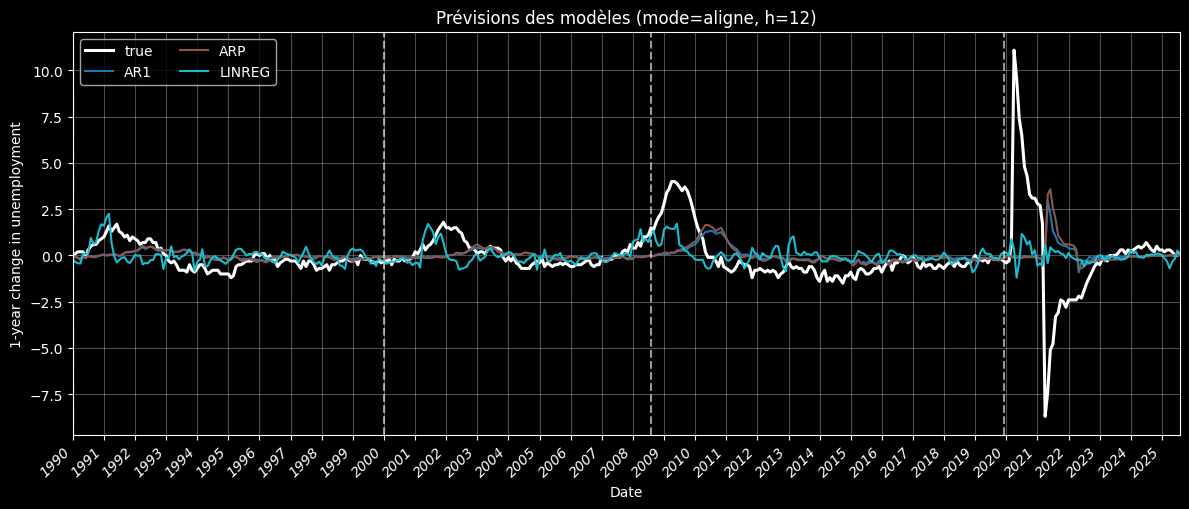

💾 Figure enregistrée → outputs\figures\global_errors.png


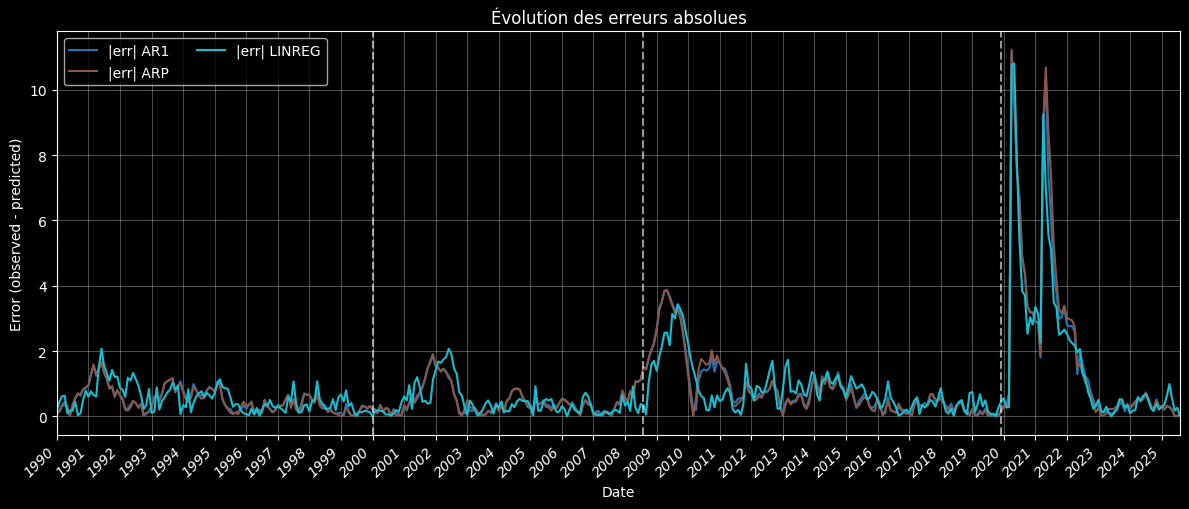

In [41]:
# =========================
# Cellule 2 — Appel (AR1, ARP, LINREG uniquement)
# =========================
segments = [
    ("1990-01-01", "1999-12-31", "1990-1999"),
    ("2000-01-01", "2008-07-31", "2000-2008"),
    ("2008-08-01", "2019-11-30", "2008-2019"),
    ("2019-12-01", None,         "2019-fin"),
]

plot_two_global_charts(
    df_pred_long,
    segments,
    H=12,
    mode="aligne",  # ou "decale"
    save=True,
    title_prefix="",
    methods_to_plot=["AR1", "ARP", "LINREG"],
    out_dir="outputs/figures",
)

# Analyse des erreurs

In [ ]:
# =========================
# Cellule 1 — Fonctions (MAE + DM)
# =========================
import numpy as np
import pandas as pd
from typing import Iterable, Optional, Tuple, List, Dict
from math import sqrt, erf, isfinite

# ----------------------------
# 0) Utilitaires
# ----------------------------
def _ensure_wide(df_wide: pd.DataFrame) -> pd.DataFrame:
    wide = df_wide.copy()
    if "date" in wide.columns:
        wide["date"] = pd.to_datetime(wide["date"], errors="coerce")
        wide = wide.set_index("date")
    if not isinstance(wide.index, pd.DatetimeIndex):
        raise ValueError("df_wide doit avoir un DatetimeIndex ou une colonne 'date' convertible en datetime.")
    wide = wide.sort_index()
    if "true" not in wide.columns:
        raise ValueError("df_wide doit contenir la colonne 'true'.")
    return wide

def _resolve_methods(wide: pd.DataFrame, methods: Optional[Iterable[str]]) -> List[str]:
    if methods is None:
        return [c for c in wide.columns if c != "true"]
    return [m for m in methods if m in wide.columns and m != "true"]

def _build_windows(
    wide: pd.DataFrame,
    periods: List[Tuple[str, Optional[str], str]],
    *,
    include_overall: bool = True,
    overall_label: str = "Ensemble",
) -> List[Tuple[pd.Timestamp, pd.Timestamp, str]]:
    full_start, full_end = wide.index.min(), wide.index.max()
    windows: List[Tuple[pd.Timestamp, pd.Timestamp, str]] = []
    if include_overall:
        windows.append((full_start, full_end, overall_label))
    for start, end, label in periods:
        s = pd.to_datetime(start)
        e = pd.to_datetime(end) if end is not None else full_end
        windows.append((s, e, label))
    return windows

# ----------------------------
# 1) MAE & erreurs par fenêtre
# ----------------------------
def _mae_and_errors_for_window(
    sub: pd.DataFrame,
    methods: List[str],
    *,
    min_obs: int = 20,
) -> Tuple[Dict[str, float], Dict[str, pd.Series]]:
    maes: Dict[str, float] = {}
    err_abs: Dict[str, pd.Series] = {}
    for m in methods:
        diffs = (sub["true"] - sub[m]).abs()
        valid = diffs.dropna()
        err_abs[m] = valid
        maes[m] = float(valid.mean()) if valid.shape[0] >= min_obs else np.nan
    return maes, err_abs

# ----------------------------
# 2) Diebold–Mariano (sans SciPy)
# ----------------------------
def _phi(z: float) -> float:
    return 0.5 * (1.0 + erf(z / sqrt(2.0)))

def _dm_pvalue(diff: np.ndarray, lags: int = 0) -> float:
    x = np.asarray(diff, dtype=float)
    x = x[np.isfinite(x)]
    T = x.size
    if T < 3:
        return np.nan

    dbar = x.mean()
    gamma0 = np.dot(x - dbar, x - dbar) / T
    var = gamma0

    if lags > 0:
        for k in range(1, min(lags, T - 1) + 1):
            w = 1.0 - k / (lags + 1.0)
            cov = np.dot(x[k:] - dbar, x[:-k] - dbar) / T
            var += 2.0 * w * cov

    if var <= 0:
        return np.nan

    stat = dbar / sqrt(var / T)
    p = 2.0 * (1.0 - _phi(abs(stat)))
    return max(0.0, min(1.0, p))

# ----------------------------
# 3) Formatage "MAE (p)"
# ----------------------------
def _format_cells_for_window(
    sub: pd.DataFrame,
    methods: List[str],
    maes: Dict[str, float],
    err_abs: Dict[str, pd.Series],
    *,
    min_obs: int,
    add_dm: bool,
    dm_lags: int,
    show_p_for_best: bool,
    round_digits: int,
    label_map: Optional[Dict[str, str]] = None,
) -> List[Tuple[str, str]]:
    finite_models = [m for m in methods if isfinite(maes.get(m, np.nan))]
    best_m = min(finite_models, key=lambda m: maes[m]) if finite_models else None

    out: List[Tuple[str, str]] = []
    for m in methods:
        label = label_map.get(m, m) if label_map else m
        mae_val = maes.get(m, np.nan)

        if not isfinite(mae_val):
            out.append((label, np.nan))
            continue

        p_txt = ""
        if add_dm and best_m is not None and m != best_m:
            v1 = err_abs[m]
            v2 = err_abs[best_m]
            common = v1.index.intersection(v2.index)
            diff = (v1.loc[common] - v2.loc[common]).values
            if diff.size >= min_obs:
                pval = _dm_pvalue(diff, lags=dm_lags)
                if isfinite(pval):
                    p_txt = f" ({pval:.3f})"
        elif add_dm and show_p_for_best and m == best_m:
            p_txt = " (—)"

        cell = f"{mae_val:.{round_digits}f}{p_txt}"
        out.append((label, cell))
    return out

# ----------------------------
# 4) Pivot final
# ----------------------------
def make_mae_dm_pivot(
    df_wide: pd.DataFrame,
    periods: List[Tuple[str, Optional[str], str]],
    *,
    methods: Optional[Iterable[str]] = None,
    include_overall: bool = True,
    overall_label: str = "Ensemble",
    min_obs: int = 20,
    round_digits: int = 4,
    add_dm: bool = True,
    dm_lags: int = 11,
    show_p_for_best: bool = False,
    label_map: Optional[Dict[str, str]] = None,
) -> pd.DataFrame:
    wide = _ensure_wide(df_wide)
    meths = _resolve_methods(wide, methods)
    if len(meths) == 0:
        return pd.DataFrame()

    windows = _build_windows(wide, periods, include_overall=include_overall, overall_label=overall_label)
    rows = []

    for start, end, label in windows:
        sub = wide.loc[start:end, ["true"] + meths].copy()
        sub = sub.dropna(subset=["true"])
        if len(sub) < min_obs:
            for m in meths:
                model_label = label_map.get(m, m) if label_map else m
                rows.append((model_label, label, np.nan))
            continue

        maes, err_abs = _mae_and_errors_for_window(sub, meths, min_obs=min_obs)

        pairs = _format_cells_for_window(
            sub=sub,
            methods=meths,
            maes=maes,
            err_abs=err_abs,
            min_obs=min_obs,
            add_dm=add_dm,
            dm_lags=dm_lags,
            show_p_for_best=show_p_for_best,
            round_digits=round_digits,
            label_map=label_map,
        )
        for model_label, cell in pairs:
            rows.append((model_label, label, cell))

    df_fmt = pd.DataFrame(rows, columns=["model", "period", "MAE_fmt"])

    desired_cols = ([overall_label] if include_overall else []) + [lbl for _, _, lbl in periods]
    pivot = df_fmt.pivot(index="model", columns="period", values="MAE_fmt").reindex(columns=desired_cols)

    order_index = [label_map.get(m, m) if label_map else m for m in meths]
    pivot = pivot.reindex(index=order_index)

    return pivot

In [44]:
# =========================
# Définition des segments temporels
# =========================
segments = [
    ("1990-01-01", "1999-12-31", "1990–1999"),
    ("2000-01-01", "2008-07-31", "2000–2008"),
    ("2008-08-01", "2019-12-30", "2008–2019"),
    ("2020-01-01", None,         "2020–fin"),
]

In [45]:
# =========================
# Cellule 2 — Construction wide + tableau MAE/DM (AR1, ARP, LINREG)
# =========================

# 1) Construire un df wide propre depuis df_pred_long (long: date,true,pred,method)
df_tmp = df_pred_long.copy()
df_tmp["date"] = pd.to_datetime(df_tmp["date"], errors="coerce")

true_by_date = df_tmp.groupby("date")["true"].median().rename("true")
wide = (
    df_tmp.pivot_table(index="date", columns="method", values="pred", aggfunc="mean")
          .sort_index()
          .join(true_by_date, how="left")
          .reset_index()
)

# 2) Méthodes à évaluer (uniquement nos 3 modèles)
methods_keep = ["AR1", "ARP", "LINREG"]

# 3) Tableau MAE (p) par segments
table_pivot = make_mae_dm_pivot(
    df_wide=wide,
    periods=segments,              # tes segments définis plus haut
    methods=methods_keep,
    include_overall=True,
    overall_label="Ensemble",
    min_obs=20,
    round_digits=4,
    add_dm=True,
    dm_lags=11,                    # h-1 si h=12
    show_p_for_best=False,
)

print("Méthodes utilisées :", methods_keep)
print(table_pivot)

Méthodes utilisées : ['AR1', 'ARP', 'LINREG']
period        Ensemble       1990–1999       2000–2008       2008–2019  \
model                                                                    
AR1     0.8670 (0.467)  0.5078 (0.109)  0.4742 (0.717)  0.8725 (0.723)   
ARP     0.8651 (0.546)          0.4951  0.4671 (0.801)  0.8460 (0.913)   
LINREG          0.8313  0.5399 (0.512)          0.4514          0.8332   

period        2020–fin  
model                   
AR1     2.0848 (0.138)  
ARP     2.1595 (0.157)  
LINREG          1.9171  
